In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import pymc as pm

from pymc_marketing.clv import GammaGammaModel, ParetoNBDModel
from pymc_marketing.clv.utils import rfm_summary
from pymc_marketing.clv import ParetoNBDModel  # or your exact transaction model class

from scipy.stats import spearmanr

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score,
    mean_absolute_percentage_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report
)

In [2]:
df_calibration = pd.read_csv('calibration.csv')
df_holdout = pd.read_csv('holdout.csv')
df_lifetimes = pd.read_csv('lifetimes.csv')

df_calibration["order_date"] = pd.to_datetime(df_calibration["order_date"])
df_holdout["order_date"] = pd.to_datetime(df_holdout["order_date"])

print('df_calibration')
df_calibration.info()

print('df_holdout')
df_holdout.info()

df_calibration
<class 'pandas.DataFrame'>
RangeIndex: 16478 entries, 0 to 16477
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       16478 non-null  int64         
 1   Customer ID      16478 non-null  int64         
 2   order_date       16478 non-null  datetime64[us]
 3   total_amount     16478 non-null  float64       
 4   number_of_items  16478 non-null  int64         
 5   Country          16478 non-null  str           
 6   order_id         16478 non-null  str           
 7   scaled_time      16478 non-null  str           
 8   scaled_time2     16478 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 1.1 MB
df_holdout
<class 'pandas.DataFrame'>
RangeIndex: 12565 entries, 0 to 12564
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 

In [3]:
df_calibration.info()

<class 'pandas.DataFrame'>
RangeIndex: 16478 entries, 0 to 16477
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       16478 non-null  int64         
 1   Customer ID      16478 non-null  int64         
 2   order_date       16478 non-null  datetime64[us]
 3   total_amount     16478 non-null  float64       
 4   number_of_items  16478 non-null  int64         
 5   Country          16478 non-null  str           
 6   order_id         16478 non-null  str           
 7   scaled_time      16478 non-null  str           
 8   scaled_time2     16478 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 1.1 MB


In [4]:
# Collaplsing 
cal_cust = df_calibration.groupby(["Customer ID",'Country'], as_index=False).agg(order_count_calibration=("order_id", "nunique"), 
                            calibration_aov=("total_amount", "mean"), calibration_spend=("total_amount", "sum"))

hold_cust = df_holdout.groupby("Customer ID", as_index=False).agg(order_count_holdout=("order_id", "nunique"), 
                            actual_aov=("total_amount", "mean"), actual_clv=("total_amount", "sum"))

In [5]:
cal_cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 4261 entries, 0 to 4260
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer ID              4261 non-null   int64  
 1   Country                  4261 non-null   str    
 2   order_count_calibration  4261 non-null   int64  
 3   calibration_aov          4261 non-null   float64
 4   calibration_spend        4261 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 166.6 KB


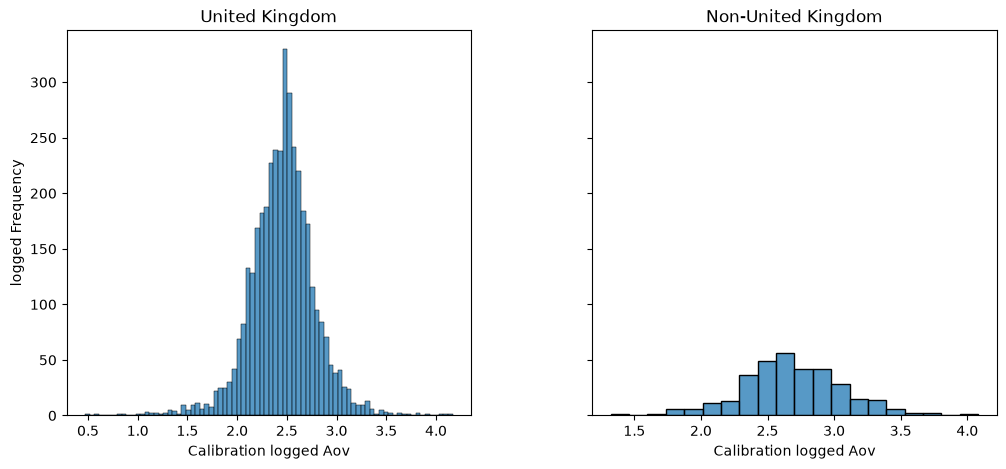

In [6]:
df_temp = cal_cust[['Customer ID', 'Country','order_count_calibration', 'calibration_aov', 'calibration_spend']].copy()
#df_temp = df_temp[df_temp["calibration_aov"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# UK customers
sns.histplot(
    np.log10(df_temp.loc[
        df_temp["Country"] == "UNITED KINGDOM",
        "calibration_aov"
    ]),
    ax=axes[0]
)

#plt.yscale("log")
axes[0].set_title("United Kingdom")
axes[0].set_xlabel("Calibration logged Aov")
axes[0].set_ylabel("logged Frequency")

# Non-UK customers
sns.histplot(
    np.log10(df_temp.loc[
        df_temp["Country"] != "UNITED KINGDOM",
        "calibration_aov"
    ]),
    #bins=30,
    ax=axes[1]
)

#plt.yscale("log")
axes[1].set_title("Non-United Kingdom")
axes[1].set_xlabel("Calibration logged Aov")
axes[1].set_ylabel("logged Frequency")

plt.subplots_adjust(wspace=0.3)
plt.show()

In [7]:
df_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 4261 entries, 0 to 4260
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer ID              4261 non-null   int64  
 1   Country                  4261 non-null   str    
 2   order_count_calibration  4261 non-null   int64  
 3   calibration_aov          4261 non-null   float64
 4   calibration_spend        4261 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 166.6 KB


In [8]:
df_temp["log10_aov"] = df_temp["calibration_aov"]
df_temp["log10_aov"].describe()

count     4261.000000
mean       412.059332
std        569.422016
min          2.950000
25%        190.575000
50%        304.066000
75%        455.528750
max      14689.460000
Name: log10_aov, dtype: float64

In [9]:
uk = df_temp.loc[df_temp["Country"] == "UNITED KINGDOM", "log10_aov"]
print(
    f"UK | n={len(uk)} | mean={uk.mean():.4f} | median={uk.median():.4f} | "
    f"sd={uk.std(ddof=1):.4f} | min={uk.min():.4f} | max={uk.max():.4f}"
)

counts = df_temp.groupby("Country").size()
special_countries = set(counts[counts <= 1].index)
special_countries.add("UNSPECIFIED")

rows = []
for _, r in df_temp[df_temp["Country"].isin(special_countries)].iterrows():
    x = r["log10_aov"]
    z = (x - uk.mean()) / uk.std(ddof=1)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    rows.append({
        "customer id": r["Customer ID"],
        "z score": z,
        "p value": p
    })

special_test = pd.DataFrame(rows).sort_values("customer id")
print(special_test.to_string(index=False))


uk = df_temp.loc[df_temp["Country"] == "UNITED KINGDOM", "log10_aov"]

special_countries.add("UNSPECIFIED")
special_countries.add("UNITED KINGDOM")

df_temp = df_temp[
    ~df_temp["Country"].isin(special_countries)
].copy()


# Descriptive stats
summary = (
    df_temp.groupby("Country")["log10_aov"]
      .agg(
          customers="size",
          mean="mean",
          median="median",
          sd="std",
          min="min",
          max="max",
      )
      .reset_index()
)

# Tests vs UK
rows = []


for c, x in df_temp.groupby("Country")["log10_aov"]:
    if c == "UNITED KINGDOM":
        continue

    x = x.dropna()

    rows.append({
        "Country": c,
        "p_welch_t": stats.ttest_ind(uk, x, equal_var=False).pvalue,
        "p_levene": stats.levene(uk, x, center="median").pvalue,
        "p_ks": stats.ks_2samp(uk, x).pvalue,
    })

tests = pd.DataFrame(rows)

result = summary.merge(tests, on="Country", how="left")

result.sort_values(by='mean', inplace=True, ascending=False)

result

UK | n=3930 | mean=385.0441 | median=295.7850 | sd=515.7157 | min=2.9500 | max=14689.4600
 customer id   z score  p value
       12347  0.439168 0.660540
       12351 -0.163102 0.870438
       12396  1.059471 0.289385
       12469  2.230349 0.025724
       12470 -0.335639 0.737143
       12744  3.168104 0.001534
       12751 -0.226431 0.820866
       12767  1.095130 0.273460
       14265  0.070855 0.943513
       15332  2.386520 0.017009
       15390  0.432963 0.665042
       15480  1.858254 0.063133
       15702 -0.610509 0.541525
       16320  1.478699 0.139221
       18140  0.293506 0.769135


,Country,customers,mean,median,sd,min,max,p_welch_t,p_levene,p_ks
21,SWITZERLAND,14,1795.429589,698.787500,3115.799990,251.575000,12079.990000,0.114146,4.804445e-17,1.027384e-04
6,DENMARK,7,1615.810286,930.486667,2014.037725,456.683333,6092.892000,0.157057,5.175032e-06,6.816493e-05
7,EIRE,3,1548.423245,1145.587097,818.976757,1008.885714,2490.796923,0.132970,2.950583e-01,1.559919e-04
12,ISRAEL,2,1485.980000,1485.980000,657.609307,1020.980000,1950.980000,0.254329,4.409065e-01,3.416772e-03
11,GREECE,4,1399.073929,1147.147857,1278.722528,227.930000,3074.070000,0.210923,1.188921e-03,5.064001e-02
16,NORWAY,4,1116.171875,1149.723750,921.270140,171.900000,1993.340000,0.210658,1.532580e-02,1.190889e-01
4,CHANNEL ISLANDS,11,1053.313788,935.825000,513.080500,302.600000,2322.430000,0.001508,4.545999e-01,7.187077e-08
20,SWEDEN,16,913.029948,594.333333,958.817644,162.000000,3802.760000,0.043742,1.034689e-03,6.366543e-03
22,UNITED ARAB EMIRATES,4,867.300000,902.320000,293.196503,479.540000,1185.020000,0.045851,9.911720e-01,3.555688e-03
14,JAPAN,5,865.847000,617.500000,700.859944,219.350000,1691.000000,0.199845,1.095825e-01,1.433548e-01


In [10]:
p_cut = 0.00

# Customers to remove (individual outliers)
customers_to_drop = set(
    special_test.loc[special_test["p value"] < p_cut, "customer id"]
)

# Countries to remove
countries_to_drop = set(
    result.loc[result["p_welch_t"] < p_cut, "Country"]
)

# Filter cal_cust
cal_cust = cal_cust[
    (~cal_cust["Customer ID"].isin(customers_to_drop)) &
    (~cal_cust["Country"].isin(countries_to_drop))
].copy()


# Filter calibration dataset

df_calibration = df_calibration[
    (~df_calibration["Customer ID"].isin(customers_to_drop)) &
    (~df_calibration["Country"].isin(countries_to_drop))
].copy()

df_clv = cal_cust.merge(hold_cust, on="Customer ID", how="left", suffixes=("_calibration", "_holdout")).fillna(0)

df_calibration['Country'].describe()

count              16478
unique                37
top       UNITED KINGDOM
freq               15190
Name: Country, dtype: object

In [11]:
print('df_calibration')
df_calibration.info()

df_calibration
<class 'pandas.DataFrame'>
RangeIndex: 16478 entries, 0 to 16477
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       16478 non-null  int64         
 1   Customer ID      16478 non-null  int64         
 2   order_date       16478 non-null  datetime64[us]
 3   total_amount     16478 non-null  float64       
 4   number_of_items  16478 non-null  int64         
 5   Country          16478 non-null  str           
 6   order_id         16478 non-null  str           
 7   scaled_time      16478 non-null  str           
 8   scaled_time2     16478 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 1.1 MB


In [12]:
print('cal_cust')
cal_cust.info()

cal_cust
<class 'pandas.DataFrame'>
RangeIndex: 4261 entries, 0 to 4260
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer ID              4261 non-null   int64  
 1   Country                  4261 non-null   str    
 2   order_count_calibration  4261 non-null   int64  
 3   calibration_aov          4261 non-null   float64
 4   calibration_spend        4261 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 166.6 KB


In [13]:
from scipy.stats import pearsonr, spearmanr

# Gamma-Gamma requires at least one repeat purchase
gg_data = cal_cust[cal_cust["order_count_calibration"] > 1].copy()

pearson_r, pearson_p = pearsonr(
    gg_data["order_count_calibration"],
    gg_data["calibration_aov"]
)

spearman_rho, spearman_p = spearmanr(
    gg_data["order_count_calibration"],
    gg_data["calibration_aov"]
)

print(f"Pearson r = {pearson_r:.4f}, p = {pearson_p:.4f}")
print(f"Spearman rho = {spearman_rho:.4f}, p = {spearman_p:.4f}")

Pearson r = 0.1512, p = 0.0000
Spearman rho = 0.1750, p = 0.0000


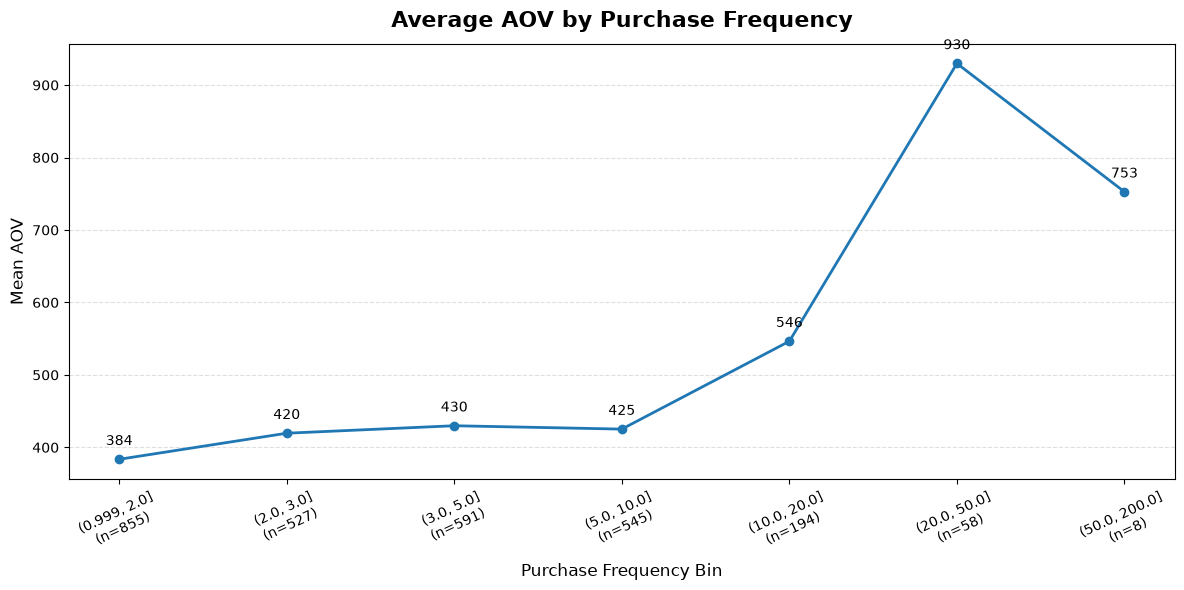

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

gg_data = cal_cust[cal_cust["order_count_calibration"] > 1].copy()

bins = [1, 2, 3, 5, 10, 20, 50, 200]
gg_data["freq_bin"] = pd.cut(gg_data["order_count_calibration"], bins=bins, include_lowest=True)

bin_summary = (
    gg_data.groupby("freq_bin", observed=True)
    .agg(mean_aov=("calibration_aov", "mean"),
         n_customers=("Customer ID", "count"))
    .reset_index()
)

labels = [f"{b}\n(n={n})" for b, n in zip(bin_summary["freq_bin"].astype(str), bin_summary["n_customers"])]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(labels, bin_summary["mean_aov"], marker="o", linewidth=2)

ax.set_title("Average AOV by Purchase Frequency", fontsize=16, fontweight="bold", pad=12)
ax.set_xlabel("Purchase Frequency Bin", fontsize=12)
ax.set_ylabel("Mean AOV", fontsize=12)
ax.tick_params(axis="x", rotation=25)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

for i, v in enumerate(bin_summary["mean_aov"]):
    ax.text(i, v + 15, f"{v:.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## Fitting Gamma-Gamma

In [15]:
# Create customer-level RFM summary
summary = rfm_summary(
    transactions=df_calibration,
    customer_id_col="Customer ID",
    datetime_col="order_date",
    monetary_value_col="total_amount",
    time_unit="D",
    include_first_transaction=True,
    sort_transactions=True,
).reset_index()

# Fit Gamma-Gamma on repeat customers only
gg_data = summary[summary["frequency"] > 0].copy()

gg_model = GammaGammaModel(data=gg_data)
gg_model.fit(method="map")

# Predict aov / expected spend for each customer
pred_aov = gg_model.expected_customer_spend(data=summary)

summary["predicted_aov"] = pred_aov.mean(("chain", "draw")).values

Output()

## Evaluation of Gamma-Gamma

In [16]:
df_clv = df_clv.merge(
    summary[["customer_id", "frequency", "monetary_value", "predicted_aov"]],
    left_on="Customer ID",
    right_on="customer_id",
    how="left"
)

df_clv = df_clv.drop(
    columns=["customer_id", "frequency", "monetary_value"]
)

print('df_clv')

df_clv.info()

df_clv
<class 'pandas.DataFrame'>
RangeIndex: 4261 entries, 0 to 4260
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer ID              4261 non-null   int64  
 1   Country                  4261 non-null   str    
 2   order_count_calibration  4261 non-null   int64  
 3   calibration_aov          4261 non-null   float64
 4   calibration_spend        4261 non-null   float64
 5   order_count_holdout      4261 non-null   float64
 6   actual_aov               4261 non-null   float64
 7   actual_clv               4261 non-null   float64
 8   predicted_aov            4261 non-null   float64
dtypes: float64(6), int64(2), str(1)
memory usage: 299.7 KB


In [72]:
w = 0.5

df_clv["predicted_aov_combined"] = (
    (1-w) * df_clv["calibration_aov"] +
    w * df_clv["predicted_aov"]
)

In [73]:
mask = df_clv["order_count_holdout"] > 0
gg_eval = df_clv[mask]

y_true = gg_eval[ "actual_aov"]
#y_pred = gg_eval["predicted_aov"]
y_pred = gg_eval["predicted_aov_combined"]
y_calib = gg_eval["calibration_aov"]

print("Gamma-Gamma Prediction Performance")
print("=" * 40)
print(f"Customers evaluated    : {len(df_clv)}")
print(f"Mean actual AOV        : {y_true.mean():.2f}")

print("Comparing Gamma-Gamma versus Holdout")
print("-" * 40)
print(f"Mean predicted AOV     : {y_pred.mean():.2f}")
print(f"MAE                    : {mean_absolute_error(y_true, y_pred):.2f}")
print(f"RMSE                   : {root_mean_squared_error(y_true, y_pred):.2f}")
print(f"R²                     : {r2_score(y_true, y_pred):.4f}")
print(f"Spearman               : {spearmanr(y_true, y_pred).correlation:.4f}")
print(f"WAPE                   : {np.abs(y_true - y_pred).sum() / y_true.sum():.4f}")

# Calibration vs Holdout
print("Comparing Calibration versus Holdout")
print("-" * 40)
print(f"Mean calibration AOV   : {y_calib.mean():.2f}")
print(f"MAE                    : {mean_absolute_error(y_true, y_calib):.2f}")
print(f"RMSE                   : {root_mean_squared_error(y_true, y_calib):.2f}")
print(f"R²                     : {r2_score(y_true, y_calib):.4f}")
print(f"Spearman               : {spearmanr(y_true, y_calib).correlation:.4f}")
print(f"WAPE                   : {np.abs(y_true - y_calib).sum() / y_true.sum():.4f}")

Gamma-Gamma Prediction Performance
Customers evaluated    : 4261
Mean actual AOV        : 434.41
Comparing Gamma-Gamma versus Holdout
----------------------------------------
Mean predicted AOV     : 443.79
MAE                    : 166.73
RMSE                   : 346.22
R²                     : 0.5555
Spearman               : 0.7026
WAPE                   : 0.3838
Comparing Calibration versus Holdout
----------------------------------------
Mean calibration AOV   : 446.17
MAE                    : 175.64
RMSE                   : 389.13
R²                     : 0.4385
Spearman               : 0.7021
WAPE                   : 0.4043


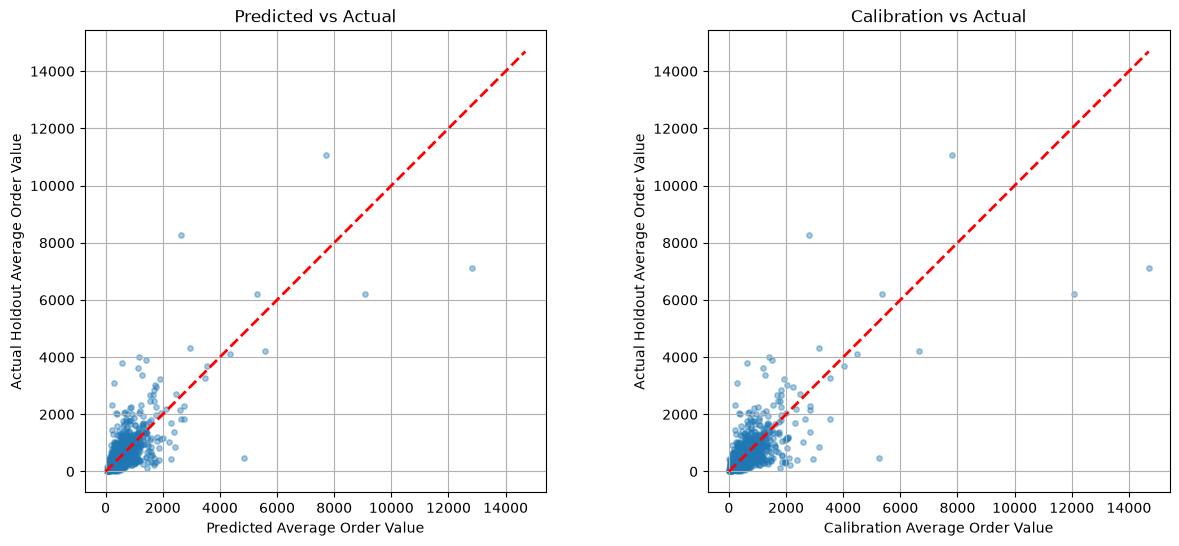

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mx = max(
    y_pred.max(),
    y_true.max(),
    y_calib.max()
)

# -----------------------------
# Predicted vs Actual
# -----------------------------
axes[0].scatter(
    y_pred,
    y_true,
    alpha=0.4,
    s=15
)

axes[0].plot([0, mx], [0, mx], "r--", linewidth=2)

axes[0].set_xlabel("Predicted Average Order Value")
axes[0].set_ylabel("Actual Holdout Average Order Value")
axes[0].set_title("Predicted vs Actual")
axes[0].grid(True)

# -----------------------------
# Calibration vs Actual
# -----------------------------
axes[1].scatter(
    y_calib,
    y_true,
    alpha=0.4,
    s=15
)

axes[1].plot([0, mx], [0, mx], "r--", linewidth=2)

axes[1].set_xlabel("Calibration Average Order Value")
axes[1].set_ylabel("Actual Holdout Average Order Value")
axes[1].set_title("Calibration vs Actual")
axes[1].grid(True)

plt.subplots_adjust(wspace=0.35)   # increase horizontal space
plt.show()

In [75]:
gg_eval["gg_error"] = (
    y_pred
    - y_true
).abs()

gg_eval["baseline_error"] = (
    y_calib
    - y_true
).abs()

gg_eval["improvement"] = (
    gg_eval["baseline_error"]
    - gg_eval["gg_error"]
)

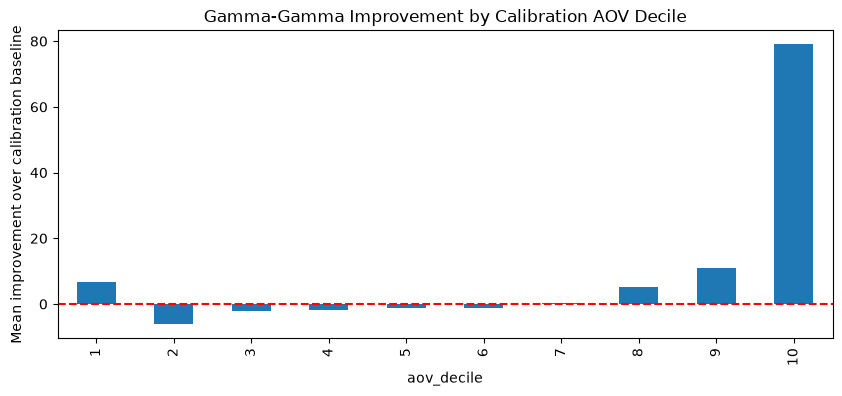

In [76]:
# Create calibration AOV deciles
gg_eval["aov_decile"] = pd.qcut(
    y_calib,
    10,
    labels=False,
    duplicates="drop"
) + 1

improvement_by_decile = (
    gg_eval
    .groupby("aov_decile")["improvement"]
    .mean()
)

improvement_by_decile.plot(kind="bar", figsize=(10,4))
plt.axhline(0, color="red", linestyle="--")
plt.ylabel("Mean improvement over calibration baseline")
plt.title("Gamma-Gamma Improvement by Calibration AOV Decile")
plt.show()

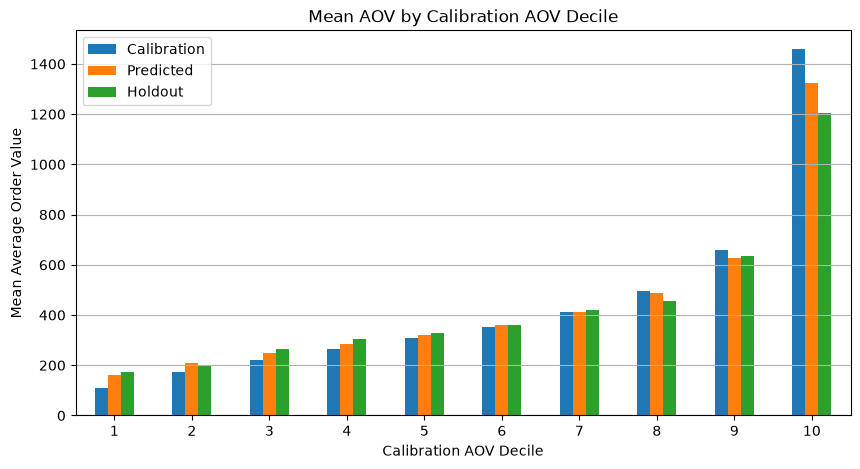

In [77]:
# Mean values by decile
decile_plot = (
    gg_eval
    .groupby("aov_decile", as_index=False)
    .agg(
        Holdout=("actual_aov", "mean"),
        Calibration=("calibration_aov", "mean"),
        Predicted=("predicted_aov_combined", "mean")
    )
)

# Plot
ax = decile_plot.plot(
    x="aov_decile",
    y=[ "Calibration", "Predicted", "Holdout"],
    kind="bar",
    figsize=(10,5)
)

ax.set_xlabel("Calibration AOV Decile")
ax.set_ylabel("Mean Average Order Value")
ax.set_title("Mean AOV by Calibration AOV Decile")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.show()

## CLV

In [25]:
df_lifetimes = pd.read_csv('lifetimes.csv')
df_lifetimes.rename(columns={'predicted_transactions':"predicted_order_count"}, inplace=True)

In [26]:
df_clv = df_clv.merge(
    df_lifetimes[
        ["customer_id", "predicted_order_count"]
    ],
    left_on="Customer ID",
    right_on="customer_id",
    how="left"
).drop(columns="customer_id")

In [27]:
df_clv["predicted_clv"] = (
    df_clv["predicted_order_count"]
    * df_clv["predicted_aov"]
)

In [28]:
df_clv["actual_clv"] = (
    df_clv["actual_clv"]
)

In [29]:
y_true = df_clv["actual_clv"]
y_pred = df_clv["predicted_clv"]

rmse = root_mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

actual_total_clv = df_clv["actual_clv"].sum()
predicted_total_clv = df_clv["predicted_clv"].sum()

print(f"Actual total CLV    : {actual_total_clv:,.2f}")
print(f"Predicted total CLV : {predicted_total_clv:,.2f}")

error = predicted_total_clv - actual_total_clv
pct_error = error / actual_total_clv * 100

print(f"Absolute error      : {error:,.2f}")
print(f"Percentage error    : {pct_error:.2f}%")

print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.4f}")

from scipy.stats import pearsonr

corr, p_value = pearsonr(y_true, y_pred)

print(f"Pearson correlation : {corr:.4f}")
print(f"P-value             : {p_value:.3e}")

from scipy.stats import spearmanr

rho, p_value = spearmanr(y_true, y_pred)

print(f"Spearman correlation : {rho:.4f}")
print(f"P-value              : {p_value:.3e}")

results = {
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2,
    "Pearson": corr,
    "Spearman": rho,
}

for metric, value in results.items():
    print(f"{metric:<10}: {value:.4f}")

Actual total CLV    : 7,026,132.87
Predicted total CLV : 8,419,594.50
Absolute error      : 1,393,461.63
Percentage error    : 19.83%
RMSE : 3853.684
MAE  : 1172.769
R²   : 0.7991
Pearson correlation : 0.9003
P-value             : 0.000e+00
Spearman correlation : 0.6213
P-value              : 0.000e+00
RMSE      : 3853.6836
MAE       : 1172.7688
R2        : 0.7991
Pearson   : 0.9003
Spearman  : 0.6213


In [30]:
summary = pd.DataFrame({
    "Metric": [
        "Actual Total CLV",
        "Predicted Total CLV",
        "Difference",
        "Percentage Error (%)"
    ],
    "Value": [
        actual_total_clv,
        predicted_total_clv,
        error,
        pct_error
    ]
})

print(summary)

                 Metric         Value
0      Actual Total CLV  7.026133e+06
1   Predicted Total CLV  8.419595e+06
2            Difference  1.393462e+06
3  Percentage Error (%)  1.983255e+01


In [31]:
actual_total_clv = df_clv["actual_clv"].sum()
predicted_total_clv = df_clv["predicted_clv"].sum()

actual_mean_clv = df_clv["actual_clv"].mean()
predicted_mean_clv = df_clv["predicted_clv"].mean()

actual_median_clv = df_clv["actual_clv"].median()
predicted_median_clv = df_clv["predicted_clv"].median()

print(f"Actual total CLV      : {actual_total_clv:,.2f}")
print(f"Predicted total CLV   : {predicted_total_clv:,.2f}")
print()

print(f"Actual mean CLV       : {actual_mean_clv:,.2f}")
print(f"Predicted mean CLV    : {predicted_mean_clv:,.2f}")
print()

print(f"Actual median CLV     : {actual_median_clv:,.2f}")
print(f"Predicted median CLV  : {predicted_median_clv:,.2f}")

Actual total CLV      : 7,026,132.87
Predicted total CLV   : 8,419,594.50

Actual mean CLV       : 1,648.94
Predicted mean CLV    : 1,975.97

Actual median CLV     : 316.68
Predicted median CLV  : 965.00


In [32]:
df_clv["clv_error"] = (
    df_clv["predicted_clv"]
    - df_clv["actual_clv"]
)

print(f"Mean Error (Bias): {df_clv['clv_error'].mean():.2f}")

mask = df_clv["actual_clv"] > 0

mape = mean_absolute_percentage_error(
    df_clv.loc[mask, "actual_clv"],
    df_clv.loc[mask, "predicted_clv"]
)

print(f"MAPE (actual CLV > 0): {mape:.2%}")

wape = (
    df_clv["clv_error"].abs().sum()
    / df_clv["actual_clv"].sum()
)

print(f"WAPE: {wape:.2%}")


summary = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R²",
        "Pearson",
        "Spearman",
        "Actual Total CLV",
        "Predicted Total CLV",
        "Actual Mean CLV",
        "Predicted Mean CLV",
        "Actual Median CLV",
        "Predicted Median CLV",
        "Bias",
        "WAPE"
    ],
    "Value": [
        rmse,
        mae,
        r2,
        corr,
        rho,
        actual_total_clv,
        predicted_total_clv,
        actual_mean_clv,
        predicted_mean_clv,
        actual_median_clv,
        predicted_median_clv,
        df_clv["clv_error"].mean(),
        wape
    ]
})

print(summary)

Mean Error (Bias): 327.03
MAPE (actual CLV > 0): 153.81%
WAPE: 71.12%
                  Metric         Value
0                   RMSE  3.853684e+03
1                    MAE  1.172769e+03
2                     R²  7.990992e-01
3                Pearson  9.003038e-01
4               Spearman  6.213204e-01
5       Actual Total CLV  7.026133e+06
6    Predicted Total CLV  8.419595e+06
7        Actual Mean CLV  1.648940e+03
8     Predicted Mean CLV  1.975967e+03
9      Actual Median CLV  3.166800e+02
10  Predicted Median CLV  9.650021e+02
11                  Bias  3.270269e+02
12                  WAPE  7.112259e-01


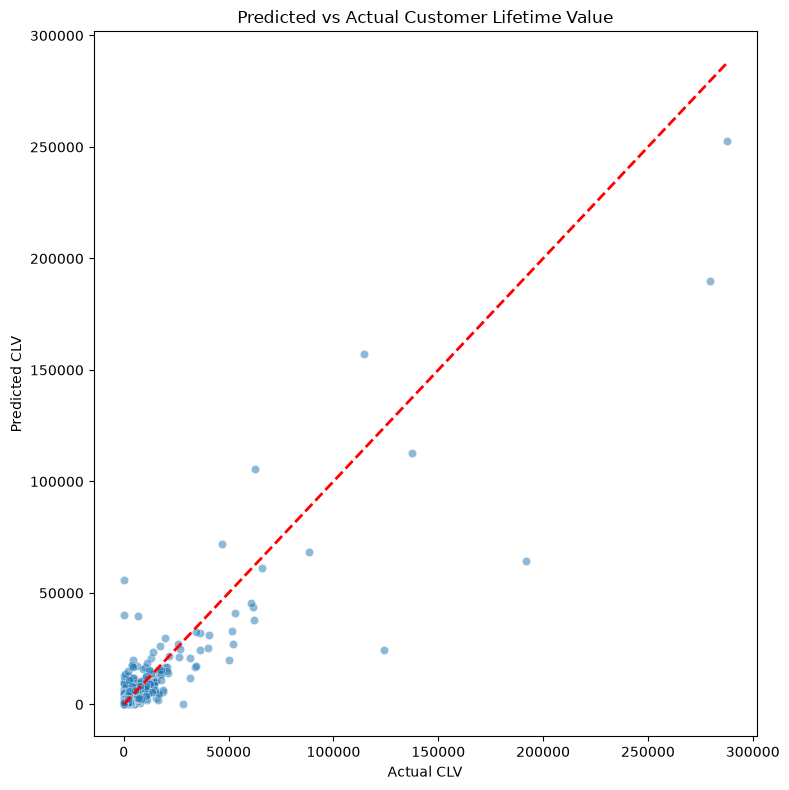

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=df_clv,
    x="actual_clv",
    y="predicted_clv",
    alpha=0.5
)

# 45-degree reference line
max_val = max(
    df_clv["actual_clv"].max(),
    df_clv["predicted_clv"].max()
)

plt.plot([0, max_val], [0, max_val], "r--", linewidth=2)

plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Predicted vs Actual Customer Lifetime Value")

plt.tight_layout()
plt.show()

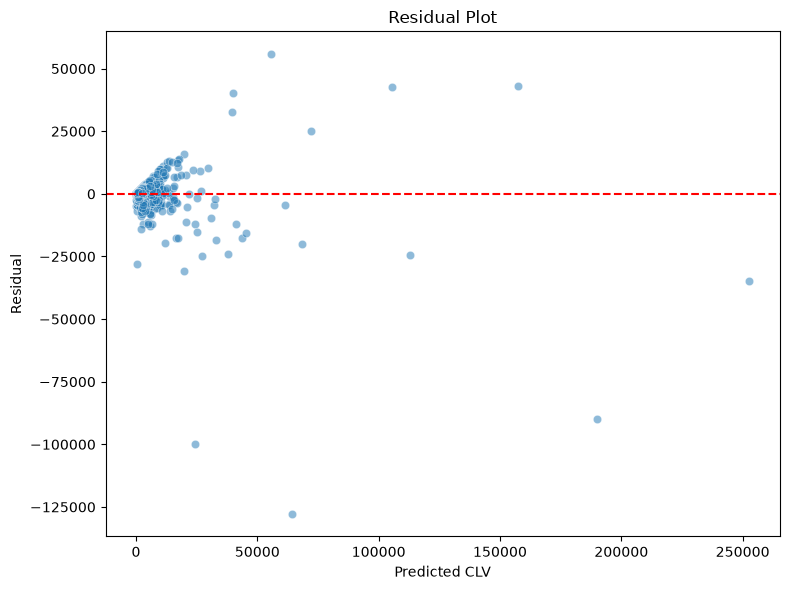

In [34]:
df_clv["residual"] = (
    df_clv["predicted_clv"]
    - df_clv["actual_clv"]
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clv,
    x="predicted_clv",
    y="residual",
    alpha=0.5
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted CLV")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

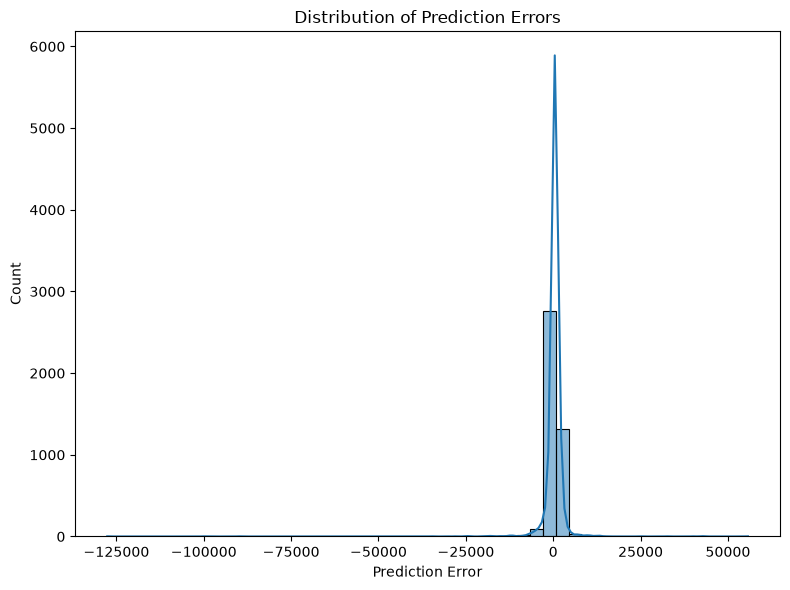

In [35]:
plt.figure(figsize=(8,6))

sns.histplot(
    df_clv["residual"],
    bins=50,
    kde=True
)

plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [36]:
df_clv["pred_decile"] = pd.qcut(
    df_clv["predicted_clv"],
    10,
    labels=False,
    duplicates="drop"
) + 1

decile_summary = (
    df_clv
    .groupby("pred_decile", observed=False)
    .agg(
        actual_mean=("actual_clv","mean"),
        predicted_mean=("predicted_clv","mean"),
        customers=("Customer ID","count")
    )
    .reset_index()
)

display(decile_summary)

,pred_decile,actual_mean,predicted_mean,customers
0,1,110.411499,225.788239,427
1,2,255.276502,355.439338,426
2,3,289.144343,517.051394,426
3,4,383.382796,680.828107,426
4,5,436.173430,866.237012,426
5,6,566.795047,1081.538600,426
6,7,830.648310,1366.464570,426
7,8,1362.801784,1857.495800,426
8,9,2094.645117,2697.872107,426
9,10,10163.731646,10115.061162,426


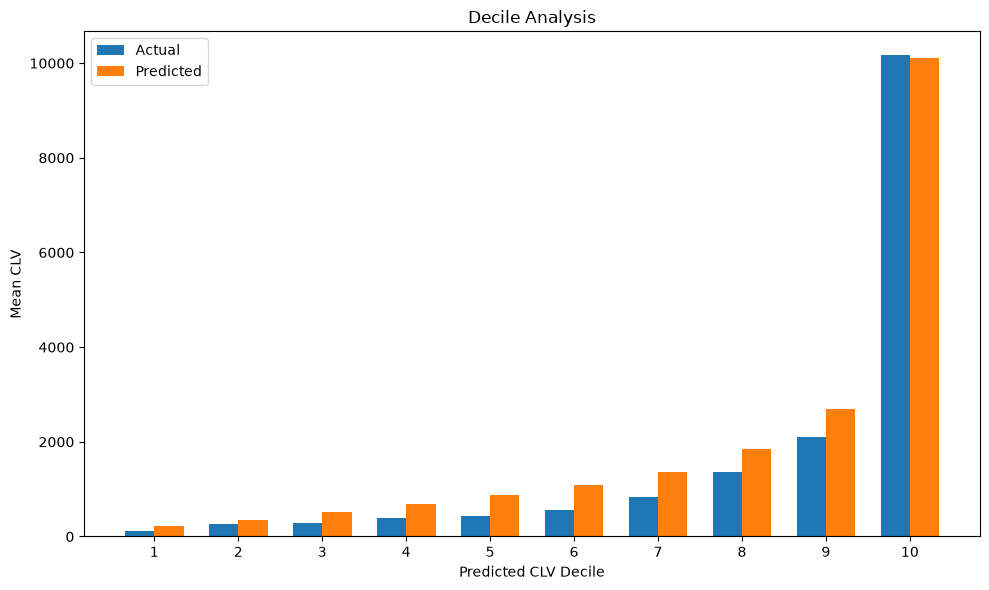

In [37]:
x = np.arange(len(decile_summary))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x-width/2,
    decile_summary["actual_mean"],
    width,
    label="Actual"
)

plt.bar(
    x+width/2,
    decile_summary["predicted_mean"],
    width,
    label="Predicted"
)

plt.xticks(x, decile_summary["pred_decile"])

plt.xlabel("Predicted CLV Decile")
plt.ylabel("Mean CLV")
plt.title("Decile Analysis")

plt.legend()

plt.tight_layout()
plt.show()

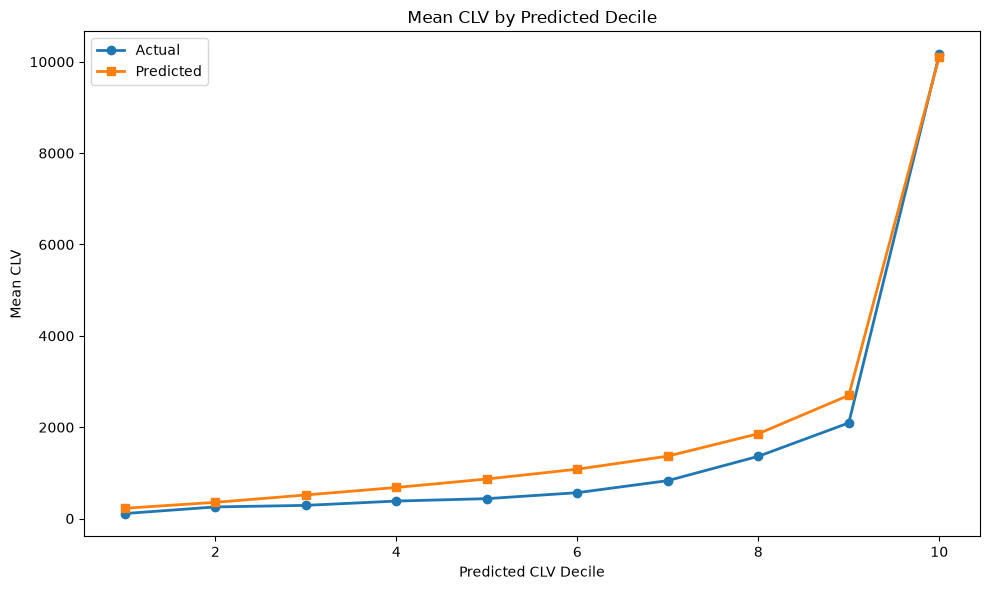

In [38]:
plt.figure(figsize=(10,6))

plt.plot(
    decile_summary["pred_decile"],
    decile_summary["actual_mean"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    decile_summary["pred_decile"],
    decile_summary["predicted_mean"],
    marker="s",
    linewidth=2,
    label="Predicted"
)

plt.xlabel("Predicted CLV Decile")
plt.ylabel("Mean CLV")
plt.title("Mean CLV by Predicted Decile")

plt.legend()

plt.tight_layout()
plt.show()

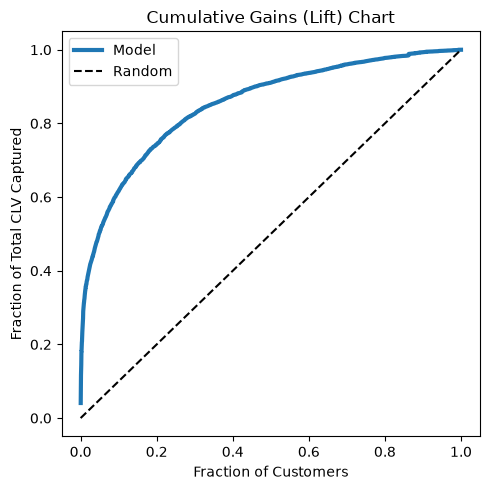

In [39]:
lift = (
    df_clv
    .sort_values("predicted_clv", ascending=False)
    .reset_index(drop=True)
)

lift["cum_actual"] = lift["actual_clv"].cumsum()
lift["cum_actual_pct"] = (
    lift["cum_actual"]
    / lift["actual_clv"].sum()
)

lift["cum_customer_pct"] = (
    np.arange(1, len(lift)+1)
    / len(lift)
)

plt.figure(figsize=(5,5))

plt.plot(
    lift["cum_customer_pct"],
    lift["cum_actual_pct"],
    linewidth=3,
    label="Model"
)

plt.plot(
    [0,1],
    [0,1],
    "k--",
    label="Random"
)

plt.xlabel("Fraction of Customers")
plt.ylabel("Fraction of Total CLV Captured")
plt.title("Cumulative Gains (Lift) Chart")

plt.legend()

plt.tight_layout()
plt.show()

In [40]:
lift = (
    df_clv
    .sort_values("predicted_clv", ascending=False)
    .reset_index(drop=True)
)

total_actual = lift["actual_clv"].sum()

for pct in [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]:
    n = int(np.ceil(len(lift) * pct))

    captured = (
        lift.iloc[:n]["actual_clv"].sum()
        / total_actual
    )

    print(f"Top {pct:>5.0%} customers capture {captured:6.2%} of actual CLV")

Top    1% customers capture 32.47% of actual CLV
Top    5% customers capture 50.60% of actual CLV
Top   10% customers capture 61.65% of actual CLV
Top   20% customers capture 74.36% of actual CLV
Top   30% customers capture 82.62% of actual CLV
Top   50% customers capture 91.07% of actual CLV
